# Современные методы анализа данных и машинного обучения, БИ

## НИУ ВШЭ, 2025-26 учебный год

# Семинар 8. API


Раннее мы с вами уже собирали данные вручную, обращаясь к html-страницам, размеченным для отображения в браузере. Однако это не единственный способ получения данных с внешних ресурсов — другим важным подходом является использование API — Application Program Interface.

Обычный интерфейс — это способ взаимодействия человека с программой, а API — одной программы с другой, например, вашего скрипта на Python — с удалённым веб-сервером.

Именно обсуждению такого прекрасного инструмента как API — а также всего, что с ним связано, — будет посвящен сегодняшний семинар.

## Язык XML

Для хранения веб-страниц, которые читают люди, используется язык HTML. Для хранения произвольных структурированных данных, которыми обмениваются между собой программы, используются другие языки — в частности, язык XML, похожий на HTML. Точнее, XML — это, на самом деле, даже не язык, а скорее метаязык — то есть способ описания языков. В отличие от HTML, набор тегов в XML-документе может быть произвольным (и определяется разработчиком конкретного диалекта XML). Например, если бы мы хотели описать в виде XML некоторую студенческую группу, это могло бы выглядеть так:

```xml
<group>
    <number>134</number>
    <student>
        <firstname>Виталий</firstname>
        <lastname>Иванов</lastname>
    </student>
    <student>
        <firstname>Мария</firstname>
        <lastname>Петрова</lastname>
    </student>
</group>
```

Для обработки XML-файлов можно использовать тот же пакет *Beautiful Soup*, который мы уже использовали для работы с HTML. Единственное различие — нужно указать дополнительный параметр `features="xml"` при вызове функции `BeautifulSoup` — чтобы он не искал в документе HTML-теги.

In [1]:
group = """<group>
<number>134</number>
<student>
<firstname>Виталий</firstname>
<lastname>Иванов</lastname>
</student>
<student>
<firstname>Мария</firstname>
<lastname>Петрова</lastname>
</student>
</group>"""

In [2]:
!pip install bs4 --quiet

In [3]:
!pip install lxml --quiet

In [4]:
from bs4 import BeautifulSoup

In [5]:
obj = BeautifulSoup(group, features="lxml")
print(obj.prettify())

<html>
 <body>
  <group>
   <number>
    134
   </number>
   <student>
    <firstname>
     Виталий
    </firstname>
    <lastname>
     Иванов
    </lastname>
   </student>
   <student>
    <firstname>
     Мария
    </firstname>
    <lastname>
     Петрова
    </lastname>
   </student>
  </group>
 </body>
</html>



Номер группы можно найти, например, вот так — для каждого объекта через точку указываем его атрибут, в который надо спуститься.

In [6]:
obj.group.number.text # последний атрибут текст, точно также как делали в html

'134'

Но это работает только тогда, когда тэг уникальный. В других случаях, парсер всегда будет попадать в первый child-тэг, который он встретил по пути вниз.

In [7]:
obj.group.student.lastname.text # до Петровой так не добраться

'Иванов'

Перечислить всех студентов можно с помощью цикла (похожая структура у нас была и в обработке html).

In [8]:
for student in obj.group.find_all('student'):
    print(student.lastname.text, student.firstname.text)

Иванов Виталий
Петрова Мария


По сути, главное отличие xml от html состоит в том, что работать вы будете не со стандартизированными структурами. Поэтому перед работой придется поиграть в детективов — запросить данные и внимательно изучить расположение узлов, чтобы понять, какие тэги вас интересуют.

## Язык JSON

Другой популярный формат, в котором клиент может отдать вам данные — это язык json. JSON расшифровывается как JavaScript Object Notation и изначально возник как подмножество языка JavaScript, используемое для описания объектов. Впрочем, впоследствии он начал использоваться и в других языках программирования, включая, конечно, Python.

Различные API могут поддерживать либо XML, либо JSON, либо и то, и другое одновременно, так что нам полезно будет научиться работать с обоими типами данных.

В целом, JSON очень похож на описание объекта в Python, и смысл квадратных и фигурных скобок здесь абсолютно такой же. Правда, есть и отличия: например, в Python одинарные и двойные кавычки ничем не отличаются, а в JSON можно использовать только двойные.

Полученный нами JSON-файл, как правило, представляет собой словарь, значения которого — строки или числа, а также списки или словари, значения которых в свою очередь также могут быть строками, числами, списками, словарями и т.д. Таким образом получается довольно сложная, ветвистая структура данных.

Впрочем, здесь очень важно сделать  ремарку, что тот факт, что перед нами сложная структура данных, видим только мы, но не программа — с точки зрения Python, j.text это просто какая-то строка. Однако в модуле requests присутствует специальный метод, позволяющий сразу выдать питоновский объект (словарь или список), если результат запроса возвращён в формате JSON. Так что нам в любом случае не придётся использовать какие-либо дополнительные библиотеки и сильно усложнять себе жизнь.

Подводя итог, хочется еще раз резюмировать, что основные преимущества JSON заключаются в том, что мы получаем готовый объект Python и нет необходимости использовать какие-то сторонние библиотеки для того, чтобы с ним работать. Недостатком является то же самое: зачастую поиск информации в XML-файле может проводиться более эффективно, чем в JSON.

## API для веб-сайтов

Прежде чем переходить к практике с API, необходимо обсудить несколько важных теоретических топиков касательно этого инструмента.

- В чем заключается принципиальная разница между подходами API и Web Scraping'a?

- Какой смысл для компаний создавать в рамках своих порталов и сайтов протоколы доступа по API? Для чего?

- Что такое API-ключ (API-токен) и зачем он нужен? Что будет, если передавать запрос по API без API-ключа?

- Существует ли какой-то универсальный интерфейс для функций API у разных ресурсов и, если да, то в чём он заключается?

- Где почитать описание доступа по API для конкретного веб-сайта, к данным которого мы хотим обратиться, используя этот протокол?

## Практика. API для КиноПоиска

Сегодня мы поработаем с неофициальным API КиноПоиска и попробуем извлечь интересные инсайты, на основе данных, к которым получим доступ.

Документация для ресурса доступна [по ссылке](https://api.kinopoisk.dev/documentation). Давайте откроем и ознакомимся с ней.

In [9]:
import requests
import json

### Подготовка

Для начала в рамках подготовки получите свой персональный API-ключ. Инструкция о том, как это сделать, представлена на сайте.

In [10]:
API_key = "XXXXXXX-XXXXXXX-XXXXXXX-XXXXXXX"

Сделаем самый базовый запрос:

In [11]:
page = requests.get(f'https://api.kinopoisk.dev/v1.4/movie/666', headers ={'accept': 'application/json', 'X-API-KEY': API_key})
page

<Response [200]>

Посмотрим на то, что пришло на выходе от сайта:

In [12]:
page.json()

{'genres': [{'name': 'боевик'}, {'name': 'триллер'}, {'name': 'криминал'}],
 'distributors': {'distributor': 'Ист-Вест'},
 'alternativeName': 'The Fast and the Furious',
 'fees': {'world': {'value': 207283925, 'currency': '$'},
  'usa': {'value': 144533925, 'currency': '$'}},
 'audience': [{'count': 25500000, 'country': 'США'},
  {'count': 1545240, 'country': 'Великобритания'},
  {'count': 1338595, 'country': 'Германия'}],
 'updatedAt': '2026-02-11T06:36:45.276Z',
 'ageRating': 18,
 'votes': {'kp': 439846,
  'imdb': 453000,
  'filmCritics': 155,
  'russianFilmCritics': 0,
  'await': 0},
 'persons': [{'id': 6317,
   'name': 'Пол Уокер',
   'enName': 'Paul Walker',
   'photo': 'https://st.kp.yandex.net/images/actor_iphone/iphone360_6317.jpg',
   'profession': 'актеры',
   'enProfession': 'actor'},
  {'id': 11437,
   'name': 'Вин Дизель',
   'enName': 'Vin Diesel',
   'photo': 'https://st.kp.yandex.net/images/actor_iphone/iphone360_11437.jpg',
   'profession': 'актеры',
   'enProfession':

### Задача 1. Драмы XXI века

Для начала поставим перед собой масштабную задачу получить информацию обо всех драмах XXI века.

Какие поля нам для этого нужно прописать?

In [13]:
request = 'https://api.kinopoisk.dev/v1.4/movie?page=1&limit=100&selectFields=id&selectFields=name&selectFields=alternativeName&selectFields=enName&selectFields=type&selectFields=year&selectFields=description&selectFields=shortDescription&selectFields=movieLength&selectFields=isSeries&selectFields=ticketsOnSale&selectFields=totalSeriesLength&selectFields=seriesLength&selectFields=ratingMpaa&selectFields=ageRating&selectFields=top10&selectFields=top250&selectFields=typeNumber&selectFields=status&selectFields=names&selectFields=logo&selectFields=poster&selectFields=backdrop&selectFields=rating&selectFields=votes&selectFields=genres&selectFields=countries&selectFields=releaseYears&type=movie&year=2000-2025&genres.name=драма'

In [14]:
page = requests.get(request, headers ={'accept': 'application/json', 'X-API-KEY': API_key})
page

<Response [200]>

Что же мы получили?

In [15]:
res = page.json()
res

{'docs': [{'typeNumber': 1,
   'ticketsOnSale': False,
   'rating': {'kp': 0,
    'imdb': 0,
    'filmCritics': 0,
    'russianFilmCritics': 0,
    'await': 0},
   'votes': {'kp': 0,
    'imdb': 0,
    'filmCritics': 0,
    'russianFilmCritics': 0,
    'await': 0},
   'genres': [{'name': 'короткометражка'}, {'name': 'драма'}],
   'type': 'movie',
   'id': 1365140,
   'alternativeName': 'Oh Baby! LaCie Collective Script to Screen',
   'year': 2019,
   'countries': [{'name': 'США'}],
   'names': [{'name': 'Oh Baby! LaCie Collective Script to Screen',
     'language': None,
     'type': 'Original title on kinopoisk'}],
   'movieLength': 2,
   'isSeries': False},
  {'votes': {'kp': 0,
    'imdb': 0,
    'filmCritics': 0,
    'russianFilmCritics': 0,
    'await': 0},
   'alternativeName': 'Que Me Lleve El Diablo',
   'genres': [{'name': 'короткометражка'}, {'name': 'драма'}],
   'year': 2014,
   'isSeries': False,
   'ticketsOnSale': False,
   'rating': {'kp': 0,
    'imdb': 0,
    'filmCri

Посмотрим, какие ключи есть в нашем словаре, и попробуем разобраться, что каждый из них означает:

In [16]:
res.keys()

dict_keys(['docs', 'total', 'limit', 'page', 'pages'])

In [17]:
len(res['docs'])

100

In [18]:
res['total'], res['limit'], res['page'], res['pages']

(206685, 100, 1, 2067)

Итого получаем следующее:

- `pages` — суммарное количество страниц,
генерирующихся по нашему запросу
- `page` — номер текущей страницы
- `limit` — максимальное количество документов (фильмов) на одной странице (задаётся нами)
- `total` — суммарное количество документов (фильмов)
- `docs` — непосредственно информация о документах (фильмах) на текущей странице


In [19]:
import pandas as pd

In [20]:
pd.DataFrame(res['docs'])['name']

,name
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
95,NaN
96,NaN
97,NaN
98,NaN


Видим, что имеется много какого-то мусора, но очистить его в масштабах всех 2000 страниц мы пока что не в состоянии. Давайте попробуем снизить наши запросы

### Задача 2. Фантастика 2023-го

Окей, предположим мы хотим вывести все фантастические фильмы за 2023 год, снятые в США и/или Великобритании. Пусть будет такой, более скромный запрос.

Подготовку будем вести уже более автоматизированным образом и пропишем отдельными переменными ключевые для нас вещи:

In [21]:
genres = ['фантастика','фэнтези']
countries = ['США', "Великобритания"]
page_id = 1

request = f'https://api.kinopoisk.dev/v1.4/movie?page={page_id}&limit=100&selectFields=id&selectFields=name&selectFields=alternativeName&selectFields=enName&selectFields=type&selectFields=year&selectFields=description&selectFields=shortDescription&selectFields=movieLength&selectFields=isSeries&selectFields=ticketsOnSale&selectFields=totalSeriesLength&selectFields=seriesLength&selectFields=ratingMpaa&selectFields=ageRating&selectFields=top10&selectFields=top250&selectFields=typeNumber&selectFields=status&selectFields=names&selectFields=logo&selectFields=poster&selectFields=backdrop&selectFields=rating&selectFields=votes&selectFields=genres&selectFields=countries&selectFields=releaseYears&type=movie&year=2023&genres.name={genres[0]}&genres.name={genres[1]}&countries.name={countries[0]}&countries.name={countries[1]}'

page = requests.get(request, headers ={'accept': 'application/json', 'X-API-KEY': API_key})
page

<Response [200]>

In [22]:
res = page.json()
res

{'docs': [{'names': [{'name': 'Portals',
     'language': None,
     'type': 'Original title on kinopoisk'}],
   'typeNumber': 1,
   'year': 2023,
   'type': 'movie',
   'isSeries': False,
   'ticketsOnSale': False,
   'rating': {'kp': 0,
    'imdb': 0,
    'filmCritics': 0,
    'russianFilmCritics': 0,
    'await': 0},
   'genres': [{'name': 'мюзикл'}, {'name': 'ужасы'}, {'name': 'фэнтези'}],
   'id': 1330600,
   'countries': [{'name': 'США'}],
   'alternativeName': 'Portals',
   'movieLength': 340,
   'votes': {'kp': 20,
    'imdb': 0,
    'filmCritics': 0,
    'russianFilmCritics': 0,
    'await': 0}},
  {'type': 'movie',
   'year': 2023,
   'isSeries': False,
   'ticketsOnSale': False,
   'countries': [{'name': 'США'}],
   'id': 1136094,
   'votes': {'kp': 0,
    'imdb': 0,
    'filmCritics': 0,
    'russianFilmCritics': 0,
    'await': 0},
   'genres': [{'name': 'фэнтези'}],
   'names': [{'name': "L'Absente",
     'language': None,
     'type': 'Original title on kinopoisk'}],
   

Посмотрим, что получится, если попробовать обернуть это в `pd.DataFrame`:

In [23]:
films_df = pd.DataFrame(res['docs'])
films_df.head(3)

,names,typeNumber,year,type,isSeries,ticketsOnSale,rating,genres,id,countries,alternativeName,movieLength,votes,description,ratingMpaa,name,poster,ageRating,shortDescription,backdrop
0,"[{'name': 'Portals', 'language': None, 'type':...",1,2023,movie,False,False,"{'kp': 0, 'imdb': 0, 'filmCritics': 0, 'russia...","[{'name': 'мюзикл'}, {'name': 'ужасы'}, {'name...",1330600,[{'name': 'США'}],Portals,340.0,"{'kp': 20, 'imdb': 0, 'filmCritics': 0, 'russi...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'name': 'L'Absente', 'language': None, 'type...",1,2023,movie,False,False,"{'kp': 0, 'imdb': 0, 'filmCritics': 0, 'russia...",[{'name': 'фэнтези'}],1136094,[{'name': 'США'}],L'Absente,NaN,"{'kp': 0, 'imdb': 0, 'filmCritics': 0, 'russia...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[{'name': 'Апория', 'language': 'RU', 'type': ...",1,2023,movie,False,False,"{'kp': 5.575, 'imdb': 5.6, 'filmCritics': 6.8,...","[{'name': 'драма'}, {'name': 'фантастика'}]",1355160,[{'name': 'США'}],Aporia,104.0,"{'kp': 397, 'imdb': 2700, 'filmCritics': 45, '...",Медсестра Софи воспитывает недружелюбно настро...,r,Апория,{'url': 'https://avatars.mds.yandex.net/get-ki...,NaN,NaN,NaN


Получилось, внезапно, очень славно — вот что означает сила словарей и их связки с Pandas'ом!

Вот только опять проблема с какими-то фильмами-ноунеймами... А еще, некоторые столбцы отображаются странно. Однозначно нужно чистить!

In [24]:
def clean_page_columns(films_df):
    films_df['rating_kp'] = films_df['rating'].apply(lambda d: d['kp'])
    films_df['rating_imdb'] = films_df['rating'].apply(lambda d: d['imdb'])

    films_df['votes_kp'] = films_df['votes'].apply(lambda d: d['kp'])
    films_df['votes_imdb'] = films_df['votes'].apply(lambda d: d['imdb'])

    films_df['genres'] = films_df['genres'].fillna('')
    films_df['countries'] = films_df['countries'].fillna('')
    films_df['genre_upd'] = films_df['genres'].apply(lambda genres: ', '.join([genre['name'] for genre in genres]))
    films_df['countries_upd'] = films_df['countries'].apply(lambda countries: ', '.join([country['name'] for country in countries]))

    films_df.set_index('id', inplace = True)

    return films_df[['name', 'rating_kp', 'rating_imdb', 'votes_kp', 'votes_imdb', 'year', 'genre_upd', 'countries_upd']]

In [25]:
def filter_noname_films(df, min_kp_votes = 500, min_imdb_votes = 500):
    df_new = df[(~(df['name'].isna())) & (df['votes_kp'] > min_kp_votes) & (df['votes_imdb'] > min_imdb_votes) & (df['rating_kp'] > 0) & (df['rating_imdb'] > 0)]
    return df_new

In [26]:
page = pd.DataFrame(res['docs'])
films_df_cleaned = clean_page_columns(page)
films_df_cleaned = filter_noname_films(films_df_cleaned)
films_df_cleaned.head()

,name,rating_kp,rating_imdb,votes_kp,votes_imdb,year,genre_upd,countries_upd
id,,,,,,,,
1319157,Гипнотик,6.741,5.5,92883,46000,2023,"боевик, триллер, детектив, фантастика","США, Великобритания, Канада"
1318868,Человек-муравей и Оса: Квантомания,5.985,6.0,71432,266000,2023,"фантастика, боевик, комедия, приключения",США
1289334,Голодные игры: Баллада о змеях и певчих птицах,7.288,6.6,214691,178000,2023,"фантастика, боевик, триллер, драма, приключени...","США, Канада"
1287544,Капитан Марвел 2,5.181,5.5,42799,161000,2023,"фантастика, боевик, приключения",США
1254077,Шазам! Ярость богов,6.004,5.9,46180,144000,2023,"фантастика, фэнтези, боевик, комедия, приключения","США, Германия, Новая Зеландия, Великобритания,..."


О, уже отлично! Теперь проделаем работу в цикле!

In [27]:
for i in range(2, res['pages'] + 1):
    genres = ['фантастика','фэнтези']
    countries = ['США', "Великобритания"]
    page_id = i

    request = f'https://api.kinopoisk.dev/v1.4/movie?page={page_id}&limit=100&selectFields=id&selectFields=name&selectFields=alternativeName&selectFields=enName&selectFields=type&selectFields=year&selectFields=description&selectFields=shortDescription&selectFields=movieLength&selectFields=isSeries&selectFields=ticketsOnSale&selectFields=totalSeriesLength&selectFields=seriesLength&selectFields=ratingMpaa&selectFields=ageRating&selectFields=top10&selectFields=top250&selectFields=typeNumber&selectFields=status&selectFields=names&selectFields=logo&selectFields=poster&selectFields=backdrop&selectFields=rating&selectFields=votes&selectFields=genres&selectFields=countries&selectFields=releaseYears&type=movie&year=2023&genres.name={genres[0]}&genres.name={genres[1]}&countries.name={countries[0]}&countries.name={countries[1]}'

    page = requests.get(request, headers ={'accept': 'application/json', 'X-API-KEY': API_key})

    res = page.json()

    page = pd.DataFrame(res['docs'])

    page_cleaned = clean_page_columns(page)
    page_cleaned = filter_noname_films(page_cleaned)

    films_df_cleaned = pd.concat([films_df_cleaned, page_cleaned])

In [28]:
films_df_cleaned

,name,rating_kp,rating_imdb,votes_kp,votes_imdb,year,genre_upd,countries_upd
id,,,,,,,,
1319157,Гипнотик,6.741,5.5,92883,46000,2023,"боевик, триллер, детектив, фантастика","США, Великобритания, Канада"
1318868,Человек-муравей и Оса: Квантомания,5.985,6.0,71432,266000,2023,"фантастика, боевик, комедия, приключения",США
1289334,Голодные игры: Баллада о змеях и певчих птицах,7.288,6.6,214691,178000,2023,"фантастика, боевик, триллер, драма, приключени...","США, Канада"
1287544,Капитан Марвел 2,5.181,5.5,42799,161000,2023,"фантастика, боевик, приключения",США
1254077,Шазам! Ярость богов,6.004,5.9,46180,144000,2023,"фантастика, фэнтези, боевик, комедия, приключения","США, Германия, Новая Зеландия, Великобритания,..."
...,...,...,...,...,...,...,...,...
542534,Особняк с привидениями,6.329,6.0,17234,50000,2023,"фэнтези, комедия, семейный","США, Канада"
507758,Токсичный мститель,6.285,5.9,32852,16000,2023,"ужасы, фантастика, боевик, комедия",США
468846,Индиана Джонс и колесо судьбы,6.454,6.5,54678,230000,2023,"фантастика, боевик, приключения",США


Замечательно! Отсортируем теперь!

In [29]:
films_df_cleaned.sort_values('rating_kp', ascending = False).head(10)

,name,rating_kp,rating_imdb,votes_kp,votes_imdb,year,genre_upd,countries_upd
id,,,,,,,,
1044280,Стражи Галактики. Часть 3,8.060,7.9,212543,462000,2023,"фантастика, боевик, комедия, приключения","США, Новая Зеландия, Франция, Канада"
4396438,Бедные-несчастные,7.606,7.8,127924,385000,2023,"драма, комедия, фантастика","Ирландия, Великобритания, США, Венгрия"
762646,Подземелья и драконы: Честь среди воров,7.428,7.2,116553,271000,2023,"фэнтези, боевик, комедия","США, Канада"
4830353,Чудесная история Генри Шугара,7.420,7.4,20038,87000,2023,"короткометражка, драма, комедия, фэнтези","США, Великобритания"
1289334,Голодные игры: Баллада о змеях и певчих птицах,7.288,6.6,214691,178000,2023,"фантастика, боевик, триллер, драма, приключени...","США, Канада"
1013343,Вонка,7.156,6.9,93030,190000,2023,"мюзикл, фэнтези, комедия, приключения, семейный","США, Великобритания, Канада"
5024991,Мы всем чужие,7.047,7.6,7427,77000,2023,"драма, мелодрама, фэнтези","Великобритания, США"
4645941,Озеро Каддо,6.935,6.8,30368,53000,2023,"фантастика, триллер, драма, детектив",США
4985730,Ты просто космос,6.797,6.4,5352,3700,2023,"фантастика, мелодрама, комедия",США


Прекрасно, наконец, что-то знакомое! :)

А если сделать критерии фильтрации помощнее? Чтобы прям только широкоизвестные были?

In [30]:
films_hype = filter_noname_films(films_df_cleaned, min_kp_votes=10000, min_imdb_votes=5000)

films_hype.sort_values('rating_kp', ascending = False).head(10)

,name,rating_kp,rating_imdb,votes_kp,votes_imdb,year,genre_upd,countries_upd
id,,,,,,,,
1044280,Стражи Галактики. Часть 3,8.060,7.9,212543,462000,2023,"фантастика, боевик, комедия, приключения","США, Новая Зеландия, Франция, Канада"
4396438,Бедные-несчастные,7.606,7.8,127924,385000,2023,"драма, комедия, фантастика","Ирландия, Великобритания, США, Венгрия"
762646,Подземелья и драконы: Честь среди воров,7.428,7.2,116553,271000,2023,"фэнтези, боевик, комедия","США, Канада"
4830353,Чудесная история Генри Шугара,7.420,7.4,20038,87000,2023,"короткометражка, драма, комедия, фэнтези","США, Великобритания"
1289334,Голодные игры: Баллада о змеях и певчих птицах,7.288,6.6,214691,178000,2023,"фантастика, боевик, триллер, драма, приключени...","США, Канада"
1013343,Вонка,7.156,6.9,93030,190000,2023,"мюзикл, фэнтези, комедия, приключения, семейный","США, Великобритания, Канада"
4645941,Озеро Каддо,6.935,6.8,30368,53000,2023,"фантастика, триллер, драма, детектив",США
1319157,Гипнотик,6.741,5.5,92883,46000,2023,"боевик, триллер, детектив, фантастика","США, Великобритания, Канада"
4631336,Джулс,6.636,6.8,10661,18000,2023,"фантастика, драма, комедия",США


Построим визуализацию оценок на КиноПоиске и на IMDb

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

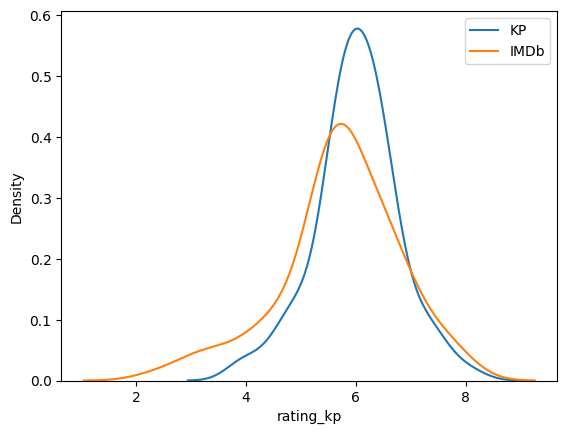

In [32]:
sns.kdeplot(films_df_cleaned['rating_kp'], label = 'KP')
sns.kdeplot(films_df_cleaned['rating_imdb'], label = 'IMDb')
plt.legend()

<Axes: xlabel='rating_kp', ylabel='rating_imdb'>

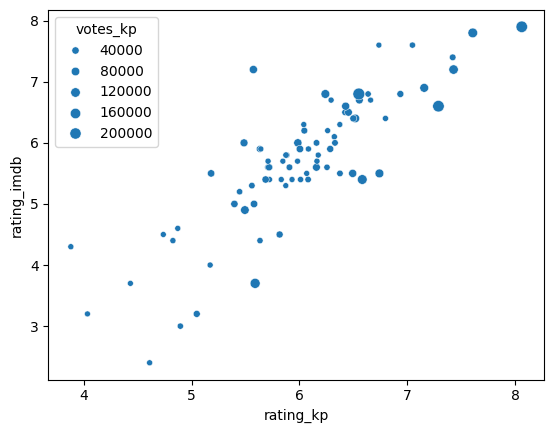

In [33]:
sns.scatterplot(data = films_df_cleaned, x = 'rating_kp', y = 'rating_imdb', size = 'votes_kp')

<Axes: >

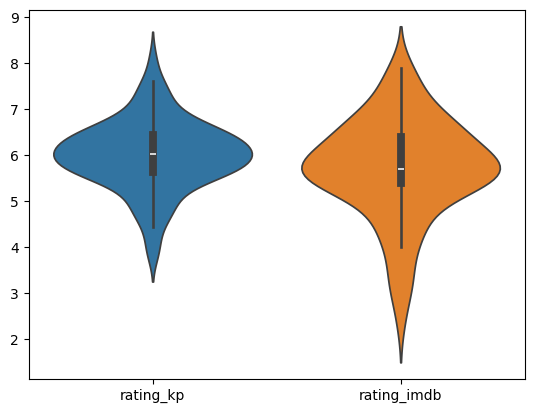

In [34]:
sns.violinplot(films_df_cleaned[['rating_kp', 'rating_imdb']])

### Задача 3: Популярность корейского кино

Исследовать рост популярности корейского кино за последнее десятилетие.

In [35]:
country = "Корея Южная"
years = "2013-2023"
page_id = 1

request = f'https://api.kinopoisk.dev/v1.4/movie?page={page_id}&limit=100&selectFields=id&selectFields=name&selectFields=alternativeName&selectFields=enName&selectFields=type&selectFields=year&selectFields=description&selectFields=shortDescription&selectFields=movieLength&selectFields=isSeries&selectFields=ticketsOnSale&selectFields=totalSeriesLength&selectFields=seriesLength&selectFields=ratingMpaa&selectFields=ageRating&selectFields=top10&selectFields=top250&selectFields=typeNumber&selectFields=status&selectFields=names&selectFields=logo&selectFields=poster&selectFields=backdrop&selectFields=rating&selectFields=votes&selectFields=genres&selectFields=countries&selectFields=releaseYears&type=movie&year={years}&countries.name={country}'

page = requests.get(request, headers ={'accept': 'application/json', 'X-API-KEY': API_key})
page

<Response [200]>

In [36]:
res = page.json()
res

{'docs': [{'alternativeName': 'Hwasa: Twit',
   'type': 'movie',
   'typeNumber': 1,
   'ticketsOnSale': False,
   'year': 2019,
   'isSeries': False,
   'rating': {'kp': 0,
    'imdb': 0,
    'filmCritics': 0,
    'russianFilmCritics': 0,
    'await': 0},
   'countries': [{'name': 'Корея Южная'}],
   'id': 1353948,
   'movieLength': 4,
   'votes': {'kp': 1,
    'imdb': 0,
    'filmCritics': 0,
    'russianFilmCritics': 0,
    'await': 0},
   'names': [{'name': 'Hwasa: Twit',
     'language': None,
     'type': 'Original title on kinopoisk'}],
   'genres': [{'name': 'короткометражка'}, {'name': 'музыка'}]},
  {'id': 1347855,
   'typeNumber': 1,
   'year': 2020,
   'countries': [{'name': 'Корея Южная'}],
   'names': [{'name': 'BTS: Outro: Ego',
     'language': None,
     'type': 'Original title on kinopoisk'}],
   'type': 'movie',
   'movieLength': 3,
   'isSeries': False,
   'rating': {'kp': 0,
    'imdb': 0,
    'filmCritics': 0,
    'russianFilmCritics': 0,
    'await': 0},
   'vote

In [37]:
films_df = pd.DataFrame(res['docs'])
films_df.head(3)

,alternativeName,type,typeNumber,ticketsOnSale,year,isSeries,rating,countries,id,movieLength,votes,names,genres,poster,name,ageRating,description,status
0,Hwasa: Twit,movie,1,False,2019,False,"{'kp': 0, 'imdb': 0, 'filmCritics': 0, 'russia...",[{'name': 'Корея Южная'}],1353948,4.0,"{'kp': 1, 'imdb': 0, 'filmCritics': 0, 'russia...","[{'name': 'Hwasa: Twit', 'language': None, 'ty...","[{'name': 'короткометражка'}, {'name': 'музыка'}]",NaN,NaN,NaN,NaN,NaN
1,BTS: Outro: Ego,movie,1,False,2020,False,"{'kp': 0, 'imdb': 0, 'filmCritics': 0, 'russia...",[{'name': 'Корея Южная'}],1347855,3.0,"{'kp': 53, 'imdb': 0, 'filmCritics': 0, 'russi...","[{'name': 'BTS: Outro: Ego', 'language': None,...","[{'name': 'короткометражка'}, {'name': 'музыка'}]",NaN,NaN,NaN,NaN,NaN
2,BTS: Black Swan,movie,1,False,2020,False,"{'kp': 0, 'imdb': 9.4, 'filmCritics': 0, 'russ...",[{'name': 'Корея Южная'}],1347023,3.0,"{'kp': 86, 'imdb': 138, 'filmCritics': 0, 'rus...","[{'name': 'BTS: Black Swan', 'language': None,...","[{'name': 'короткометражка'}, {'name': 'музыка'}]",NaN,NaN,NaN,NaN,NaN


In [38]:
page = pd.DataFrame(res['docs'])
films_df_cleaned = clean_page_columns(page)
films_df_cleaned = filter_noname_films(films_df_cleaned)
films_df_cleaned.head()

,name,rating_kp,rating_imdb,votes_kp,votes_imdb,year,genre_upd,countries_upd
id,,,,,,,,
1278185,BTS: Открой свою душу. Фильм,8.264,8.4,5117,3100,2019,"документальный, музыка, концерт",Корея Южная
1219911,BTS: Love Yourself Tour in Seoul,8.205,8.8,6525,2300,2019,"документальный, музыка, концерт",Корея Южная
1200750,Выжги сцену: Фильм,8.717,8.5,3218,4500,2018,"документальный, музыка, концерт",Корея Южная


In [39]:
from tqdm import tqdm

In [40]:
for i in range(2, res['pages'] + 1):
    country = "Корея Южная"
    years = "2013-2023"
    page_id = i

    request = f'https://api.kinopoisk.dev/v1.4/movie?page={page_id}&limit=100&selectFields=id&selectFields=name&selectFields=alternativeName&selectFields=enName&selectFields=type&selectFields=year&selectFields=description&selectFields=shortDescription&selectFields=movieLength&selectFields=isSeries&selectFields=ticketsOnSale&selectFields=totalSeriesLength&selectFields=seriesLength&selectFields=ratingMpaa&selectFields=ageRating&selectFields=top10&selectFields=top250&selectFields=typeNumber&selectFields=status&selectFields=names&selectFields=logo&selectFields=poster&selectFields=backdrop&selectFields=rating&selectFields=votes&selectFields=genres&selectFields=countries&selectFields=releaseYears&type=movie&year={years}&countries.name={country}'

    page = requests.get(request, headers ={'accept': 'application/json', 'X-API-KEY': API_key})

    res = page.json()

    page = pd.DataFrame(res['docs'])

    page_cleaned = clean_page_columns(page)
    page_cleaned = filter_noname_films(page_cleaned)

    films_df_cleaned = pd.concat([films_df_cleaned, page_cleaned])

In [41]:
films_df_cleaned.head()

,name,rating_kp,rating_imdb,votes_kp,votes_imdb,year,genre_upd,countries_upd
id,,,,,,,,
1278185,BTS: Открой свою душу. Фильм,8.264,8.4,5117,3100,2019,"документальный, музыка, концерт",Корея Южная
1219911,BTS: Love Yourself Tour in Seoul,8.205,8.8,6525,2300,2019,"документальный, музыка, концерт",Корея Южная
1200750,Выжги сцену: Фильм,8.717,8.5,3218,4500,2018,"документальный, музыка, концерт",Корея Южная
1348101,Сделка с дьяволом,6.556,6.2,932,652,2023,"криминал, триллер",Корея Южная
1346482,Прошлые жизни,7.384,7.8,83756,168000,2023,мелодрама,"США, Корея Южная"


Сгруппируем по годам:

In [42]:
df_groupped_korea = films_df_cleaned.groupby('year')[['rating_kp', 'rating_imdb']].mean()
df_groupped_korea

,rating_kp,rating_imdb
year,,
2013,6.839531,6.618750
2014,6.817179,6.556410
2015,6.731969,6.521875
2016,6.828625,6.728125
2017,6.852791,6.711628
2018,6.748513,6.592308
2019,6.685881,6.585714
2020,6.793963,6.514815
2021,6.900000,6.545833


И, конечно, графики:

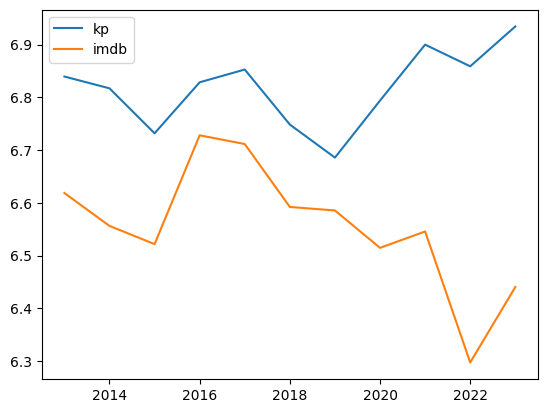

In [43]:
plt.plot(df_groupped_korea.index, df_groupped_korea['rating_kp'], label = 'kp')
plt.plot(df_groupped_korea.index, df_groupped_korea['rating_imdb'], label = 'imdb')

plt.legend()

plt.show()

### Задача 4: Фильмы с Тимоти Шаламе <3

Вывести самые высоко оценненые фильмы с Тимоти Шаламе за его карьеру

Найдем в интернете ID актера — Тимоти Шаламе:

In [44]:
actor_id = "1665224"
years = "2000-2025"
page_id = 1

request = f'https://api.kinopoisk.dev/v1.4/movie?page={page_id}&limit=100&selectFields=id&selectFields=name&selectFields=alternativeName&selectFields=enName&selectFields=type&selectFields=year&selectFields=description&selectFields=shortDescription&selectFields=movieLength&selectFields=isSeries&selectFields=ticketsOnSale&selectFields=totalSeriesLength&selectFields=seriesLength&selectFields=ratingMpaa&selectFields=ageRating&selectFields=top10&selectFields=top250&selectFields=typeNumber&selectFields=status&selectFields=names&selectFields=logo&selectFields=poster&selectFields=backdrop&selectFields=rating&selectFields=votes&selectFields=genres&selectFields=countries&selectFields=releaseYears&type=movie&year={years}&persons.id={actor_id}'

page = requests.get(request, headers ={'accept': 'application/json', 'X-API-KEY': API_key})
page

<Response [200]>

In [45]:
res = page.json()
res

{'docs': [{'alternativeName': '92nd Annual Academy Awards',
   'year': 2020,
   'poster': {'url': 'https://avatars.mds.yandex.net/get-kinopoisk-image/1599028/441c1b58-632e-48a7-9e8b-cffea7201107/600x900',
    'previewUrl': 'https://avatars.mds.yandex.net/get-kinopoisk-image/1599028/441c1b58-632e-48a7-9e8b-cffea7201107/300x450'},
   'genres': [{'name': 'церемония'}, {'name': 'музыка'}],
   'countries': [{'name': 'США'}],
   'id': 1322864,
   'name': '92-я церемония вручения премии «Оскар»',
   'type': 'movie',
   'typeNumber': 1,
   'movieLength': 170,
   'isSeries': False,
   'ticketsOnSale': False,
   'rating': {'kp': 6.805,
    'imdb': 6.6,
    'filmCritics': 0,
    'russianFilmCritics': 0,
    'await': 0},
   'names': [{'name': '92-я церемония вручения премии «Оскар»',
     'language': 'RU',
     'type': 'Russian title on kinopoisk'},
    {'name': '92nd Annual Academy Awards',
     'language': None,
     'type': 'Original title on kinopoisk'}],
   'votes': {'kp': 611,
    'imdb': 14

In [46]:
films_df = pd.DataFrame(res['docs'])
films_df.head(3)

,alternativeName,year,poster,genres,countries,id,name,type,typeNumber,movieLength,isSeries,ticketsOnSale,rating,names,votes,description,ageRating,ratingMpaa,shortDescription,backdrop
0,92nd Annual Academy Awards,2020,{'url': 'https://avatars.mds.yandex.net/get-ki...,"[{'name': 'церемония'}, {'name': 'музыка'}]",[{'name': 'США'}],1322864,92-я церемония вручения премии «Оскар»,movie,1,170.0,False,False,"{'kp': 6.805, 'imdb': 6.6, 'filmCritics': 0, '...",[{'name': '92-я церемония вручения премии «Оск...,"{'kp': 611, 'imdb': 1400, 'filmCritics': 0, 'r...",NaN,NaN,NaN,NaN,NaN
1,2019 Golden Globe Awards,2019,NaN,"[{'name': 'реальное ТВ'}, {'name': 'комедия'},...",[{'name': 'США'}],1252322,76-я церемония вручения премии «Золотой глобус»,movie,1,145.0,False,False,"{'kp': 0, 'imdb': 5.5, 'filmCritics': 0, 'russ...",[{'name': '76-я церемония вручения премии «Зол...,"{'kp': 115, 'imdb': 508, 'filmCritics': 0, 'ru...",NaN,NaN,NaN,NaN,NaN
2,Great Performers: Horror Show,2017,{'url': 'https://avatars.mds.yandex.net/get-ki...,"[{'name': 'короткометражка'}, {'name': 'ужасы'}]",[{'name': 'США'}],1132268,Великие артисты: Шоу ужасов,movie,1,10.0,False,False,"{'kp': 6.52, 'imdb': 6.4, 'filmCritics': 0, 'r...","[{'name': 'Великие артисты: Шоу ужасов', 'lang...","{'kp': 132, 'imdb': 380, 'filmCritics': 0, 'ru...",NaN,NaN,NaN,NaN,NaN


In [47]:
films_df_cleaned = clean_page_columns(films_df)
films_df_cleaned = filter_noname_films(films_df_cleaned)
films_df_cleaned.head()

,name,rating_kp,rating_imdb,votes_kp,votes_imdb,year,genre_upd,countries_upd
id,,,,,,,,
1322864,92-я церемония вручения премии «Оскар»,6.805,6.6,611,1400,2020,"церемония, музыка",США
1338480,Не смотрите наверх,7.478,7.1,315986,663000,2021,"драма, фантастика, комедия","США, Канада"
1211076,Французский вестник. Приложение к газете «Либе...,7.469,7.1,83790,165000,2020,"драма, мелодрама, комедия","США, Германия, Швеция, Франция, Великобритания"
1114570,Король Англии,7.132,7.3,65578,175000,2019,"биография, драма, военный, история","Великобритания, Венгрия, США, Австралия"
6290547,Марти Великолепный,7.755,8.1,43245,63000,2025,"драма, комедия, спорт",США


In [48]:
df_shalame = films_df_cleaned.sort_values('rating_kp', ascending=False)
df_shalame.head(10)

,name,rating_kp,rating_imdb,votes_kp,votes_imdb,year,genre_upd,countries_upd
id,,,,,,,,
258687,Интерстеллар,8.671,8.7,1122439,2500000,2014,"фантастика, драма, приключения","США, Великобритания, Канада"
4540126,Дюна: Часть вторая,8.178,8.4,216537,715000,2024,"фантастика, боевик, драма, приключения","США, Канада, ОАЭ, Венгрия, Италия, Новая Зелан..."
807339,Маленькие женщины,7.819,7.8,268662,280000,2019,"драма, мелодрама",США
6290547,Марти Великолепный,7.755,8.1,43245,63000,2025,"драма, комедия, спорт",США
409424,Дюна,7.673,8.0,828036,1000000,2021,"фантастика, боевик, драма, приключения","США, Канада, Венгрия"
979148,Назови меня своим именем,7.630,7.8,182066,354000,2017,"драма, мелодрама","Бразилия, Франция, Италия, США"
1338480,Не смотрите наверх,7.478,7.1,315986,663000,2021,"драма, фантастика, комедия","США, Канада"
1211076,Французский вестник. Приложение к газете «Либе...,7.469,7.1,83790,165000,2020,"драма, мелодрама, комедия","США, Германия, Швеция, Франция, Великобритания"
963016,Недруги,7.444,7.2,185304,106000,2017,"драма, вестерн",США


### Задача 5: Самые длинные фантастические сериалы

Найти ТОП-10 самых длинных фантастических сериалов.

In [49]:
genres = ["фантастика", "фэнтези"]
page_id = 1

request = f'https://api.kinopoisk.dev/v1.4/movie?page={page_id}&limit=100&selectFields=id&selectFields=name&selectFields=alternativeName&selectFields=enName&selectFields=type&selectFields=year&selectFields=description&selectFields=shortDescription&selectFields=movieLength&selectFields=isSeries&selectFields=ticketsOnSale&selectFields=totalSeriesLength&selectFields=seriesLength&selectFields=ratingMpaa&selectFields=ageRating&selectFields=top10&selectFields=top250&selectFields=typeNumber&selectFields=status&selectFields=names&selectFields=logo&selectFields=poster&selectFields=backdrop&selectFields=rating&selectFields=votes&selectFields=genres&selectFields=countries&selectFields=releaseYears&type=tv-series&sortField=totalSeriesLength&sortType=-1&genres.name={genres[0]}&genres.name={genres[1]}'

page = requests.get(request, headers ={'accept': 'application/json', 'X-API-KEY': API_key})
page

<Response [200]>

In [50]:
res = page.json()
res

{'docs': [{'alternativeName': 'Rauzán',
   'typeNumber': 2,
   'seriesLength': 45,
   'totalSeriesLength': 4500,
   'ticketsOnSale': False,
   'votes': {'kp': 514,
    'imdb': 50,
    'filmCritics': 0,
    'russianFilmCritics': 0,
    'await': 0},
   'countries': [{'name': 'Колумбия'}],
   'id': 419572,
   'type': 'tv-series',
   'year': 2000,
   'description': 'Себастьян де Монтоза красив и богат, но страдает каталепсией - унаследованной от отца болезнью, от которой вскоре должен умереть. Молодой человек известен как загадочный, эксцентричный ловелас, который соблазняет самых красивых девушек, а потом безжалостно их бросает. \n\nНо в один прекрасный день он влюбляется в богатую красавицу Соледад де Сантино и решает на ней жениться... Но на его пути возникает сразу несколько препятствий. Во-первых, это его собственный брат, а во-вторых, девушка, которую он любил, и которая ждет от него ребенка, считает его мертвым, потому что после очередного приступа его похоронили заживо...',
   'rat

In [51]:
films_df = pd.DataFrame(res['docs'])
films_df.head(3)

,alternativeName,typeNumber,seriesLength,totalSeriesLength,ticketsOnSale,votes,countries,id,type,year,...,poster,genres,isSeries,releaseYears,names,name,ageRating,shortDescription,backdrop,ratingMpaa
0,Rauzán,2,45.0,4500,False,"{'kp': 514, 'imdb': 50, 'filmCritics': 0, 'rus...",[{'name': 'Колумбия'}],419572,tv-series,2000,...,{'url': 'https://avatars.mds.yandex.net/get-ki...,"[{'name': 'фэнтези'}, {'name': 'драма'}, {'nam...",True,"[{'start': 2000, 'end': 2001}]","[{'name': 'Раузан', 'language': 'RU', 'type': ...",Раузан,NaN,NaN,NaN,NaN
1,El ministerio del tiempo,2,70.0,3155,False,"{'kp': 5134, 'imdb': 6000, 'filmCritics': 0, '...",[{'name': 'Испания'}],891645,tv-series,2015,...,{'url': 'https://avatars.mds.yandex.net/get-ki...,"[{'name': 'фантастика'}, {'name': 'комедия'}, ...",True,"[{'start': 2015, 'end': 2020}]","[{'name': 'Министерство времени', 'language': ...",Министерство времени,18.0,NaN,NaN,NaN
2,Baramui nara,2,60.0,2160,False,"{'kp': 1858, 'imdb': 1700, 'filmCritics': 0, '...",[{'name': 'Корея Южная'}],494493,tv-series,2008,...,{'url': 'https://avatars.mds.yandex.net/get-ki...,"[{'name': 'фэнтези'}, {'name': 'драма'}, {'nam...",True,"[{'start': 2008, 'end': 2008}]","[{'name': 'Королевство ветров', 'language': 'R...",Королевство ветров,NaN,NaN,NaN,NaN


In [52]:
def clean_series(series):
    series['genre'] = series['genres'].apply(lambda genres: ', '.join([genre['name'] for genre in genres]))
    series['countries'] = series['countries'].apply(lambda countries: ', '.join([country['name'] for country in countries]))

    series['release_start'] = series['releaseYears'].apply(lambda x: x[0]['start'] if 'start' in x[0] else 'Unknown')
    series['release_end'] = series['releaseYears'].apply(lambda x: x[0]['end'] if 'end' in x[0] else 'Unknown')

    series.set_index('id', inplace = True)

    return series[['name', 'year', 'genre', 'countries', 'release_start', 'release_end', 'seriesLength', 'totalSeriesLength']]

Есть ли в топ-100 самых длинных сериалов сериалы из России?

In [53]:
cleaned100series = clean_series(films_df)
cleaned100series.head()

,name,year,genre,countries,release_start,release_end,seriesLength,totalSeriesLength
id,,,,,,,,
419572,Раузан,2000,"фэнтези, драма, мелодрама",Колумбия,2000,2001,45.0,4500
891645,Министерство времени,2015,"фантастика, комедия, приключения",Испания,2015,2020,70.0,3155
494493,Королевство ветров,2008,"фэнтези, драма, история",Корея Южная,2008,2008,60.0,2160
5028856,Сердце спасателя,2022,"комедия, фэнтези, драма, мелодрама, детектив",Таиланд,2022,2022,39.0,1755
5211444,Лунное пророчество,2019,"мелодрама, фэнтези",Таиланд,2019,2019,110.0,1540


In [54]:
cleaned100series[cleaned100series['countries'].str.contains("Россия")]

,name,year,genre,countries,release_start,release_end,seriesLength,totalSeriesLength
id,,,,,,,,
717443,До смерти красива,2013,"фантастика, драма, комедия",Россия,2013,2013,46.0,1104
674374,Я отменяю смерть,2012,"детектив, триллер, фэнтези, мелодрама",Россия,2012,2012,45.0,1080
622652,Обратная сторона Луны,2012,"фантастика, триллер, драма, криминал, детектив",Россия,2012,2016,50.0,800
841702,Иные,2014,"фантастика, драма, триллер",Россия,2014,2014,48.0,768
533136,Шахта,2010,"фантастика, боевик, драма, детектив",Россия,2010,2010,48.0,768
256766,Охота на гения,2006,"фантастика, криминал, детектив, приключения",Россия,2006,2006,44.0,704
428836,Энигма,2010,"фантастика, триллер, приключения",Россия,2010,2010,47.0,686
487349,Гадание при свечах,2010,"фантастика, мелодрама",Россия,2010,2010,42.0,680
394028,Девять неизвестных,2006,"фэнтези, детектив",Россия,2006,2006,NaN,624


### Творческая часть

Придумайте какую-нибудь свою интересную и масштабную задачу, которую можно было бы решить в рамках имеющихся у нас данных. В идеале — сразу обосновать, какую пользу или интерес решение такой задачи могло бы нести.

Давайте вместе реализуем самые интересные и нетривиальные из ваших предложений!

    # your ideas here